# 01a — Arquitectura Transformer

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/01a-transformer.ipynb)

> Este tema forma parte del **Bloque 1 — Fundamentos**. Se recomienda
> seguir el orden propuesto: Transformer → LLMs → Embeddings → Vector
> DB.

> Para situar esta arquitectura en la evolución de las representaciones,
> consulta antes el [panorama histórico: del texto a los
> embeddings](00-panorama.qmd). La sección explica por qué los
> embeddings de palabras son anteriores al Transformer y por qué BERT y
> SBERT aprovechan después esta arquitectura.

In [1]:
!pip install -q matplotlib

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

## Arquitectura Transformer

### El problema que resuelve

Antes del Transformer, buena parte del procesamiento de lenguaje se
apoyaba en modelos recurrentes como RNN, LSTM y GRU. Estos modelos
actualizaban un estado oculto después de leer cada token, de modo que el
procesamiento de una posición dependía del resultado de la posición
anterior.

Ese diseño planteaba tres dificultades. La primera era la falta de
paralelismo: no se podía procesar una secuencia completa de una sola
vez. La segunda era el deterioro de las señales de gradiente en
secuencias largas. La tercera era la dificultad de relacionar
directamente dos tokens muy alejados, porque la información tenía que
atravesar todos los estados intermedios.

El Transformer (Vaswani et al. (2017)) sustituyó la recurrencia por
atención. La atención permite que cada posición combine información de
otras posiciones mediante una operación matricial que se puede calcular
en paralelo durante el entrenamiento. Esta ventaja no elimina el coste:
la atención densa compara pares de posiciones y su coste crece
cuadráticamente con la longitud de la secuencia.

> **La idea de fondo**
>
> Una RNN transporta información paso a paso. Un Transformer construye
> cada representación consultando directamente otras posiciones,
> respetando la máscara de atención que corresponda.

### Cómo funciona un Transformer de un vistazo

Un Transformer es una arquitectura que transforma una secuencia de
representaciones en otra secuencia de representaciones. Según la
variante y la cabeza de salida, puede producir embeddings, etiquetas de
clasificación o una distribución de probabilidad sobre el vocabulario.
En un LLM decoder-only, el recorrido se puede resumir así: texto →
tokens → IDs → embeddings → bloques Transformer → logits → texto.

<figure id="fig-pipeline-transformer">
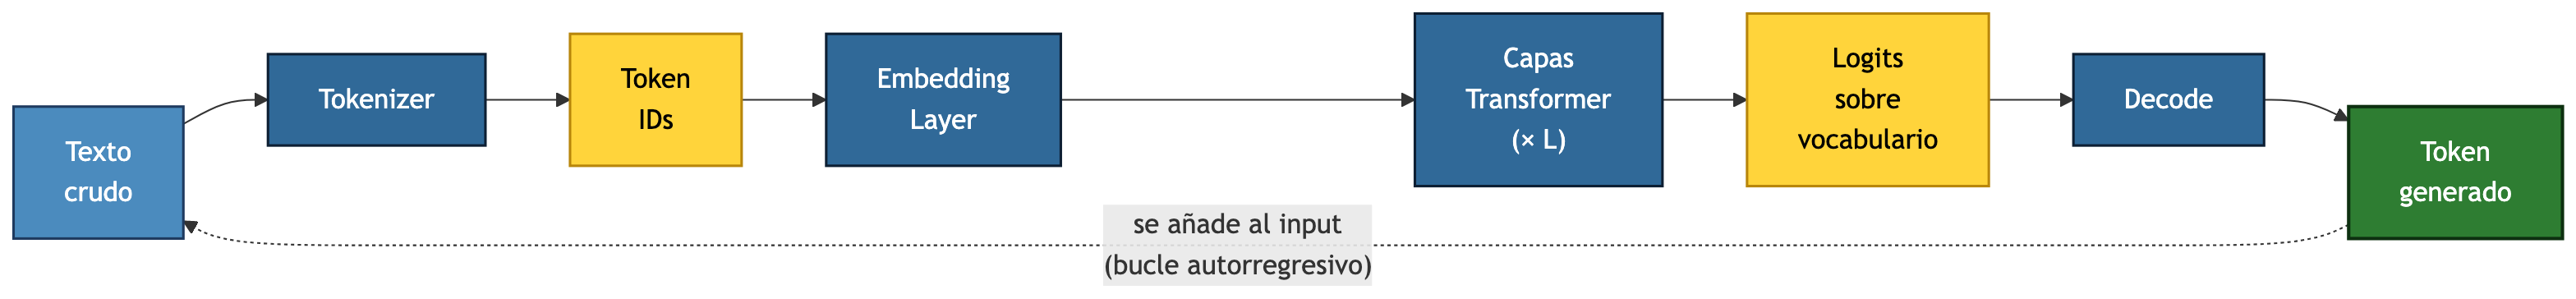
<figcaption>Figura 1</figcaption>
</figure>

Durante la inferencia generativa, la salida se obtiene un token cada
vez. La flecha discontinua muestra el bucle autorregresivo: el token
recién generado se incorpora al contexto y el modelo calcula la
siguiente distribución. Durante el entrenamiento, en cambio, una
secuencia completa puede procesarse en paralelo mediante *teacher
forcing* y una máscara causal.

> **Las 4 etapas de la pipeline**
>
> 1.  **Tokenización** — el texto se divide en unidades subpalabra
>     (tokens). Por ejemplo, *“unhappiness”* puede descomponerse en
>     `["un", "happiness"]` o `["unhapp", "iness"]`. Cada token recibe
>     un **ID entero** del vocabulario del modelo.
> 2.  **Embedding** — cada ID se convierte en un **vector denso** de
>     dimensión $d$ (típicamente $d = 4096$). Los vectores se eligen de
>     modo que **conceptos similares caen cerca en el espacio
>     vectorial**.
> 3.  **Procesamiento contextual** — $L$ capas de Transformer
>     transforman todos los estados en paralelo. En un encoder cada
>     posición puede consultar toda la secuencia; en un decoder-only
>     solo puede consultar las posiciones anteriores y la actual. Tras
>     $L$ capas, cada posición codifica información contextual.
> 4.  **Predicción** — el estado oculto final se proyecta a una
>     distribución de probabilidad sobre todo el vocabulario, y una
>     estrategia de *decoding* (temperatura, top-p, top-k) elige el
>     siguiente token.
>
> Las secciones que siguen desglosan **cómo** funciona cada etapa,
> empezando por la pieza central: la **atención multi-cabeza**.

> **Lectura intuitiva: qué recordar**
>
> - Un Transformer no opera directamente con palabras: opera con
>   vectores aprendidos.
> - La atención permite mezclar información entre posiciones, pero la
>   máscara determina qué posiciones están disponibles.
> - La generación produce un token cada vez (autorregresiva), aunque el
>   entrenamiento puede procesar muchas posiciones en paralelo.

### Del Transformer original al decoder-only moderno

El artículo original de Vaswani et al. presentó un modelo
encoder-decoder para tareas de secuencia a secuencia, como traducción y
resumen. El encoder leía toda la entrada con atención bidireccional; el
decoder generaba la salida de izquierda a derecha y utilizaba
cross-attention para consultar las representaciones producidas por el
encoder.

<figure id="fig-arquitectura-transformer">
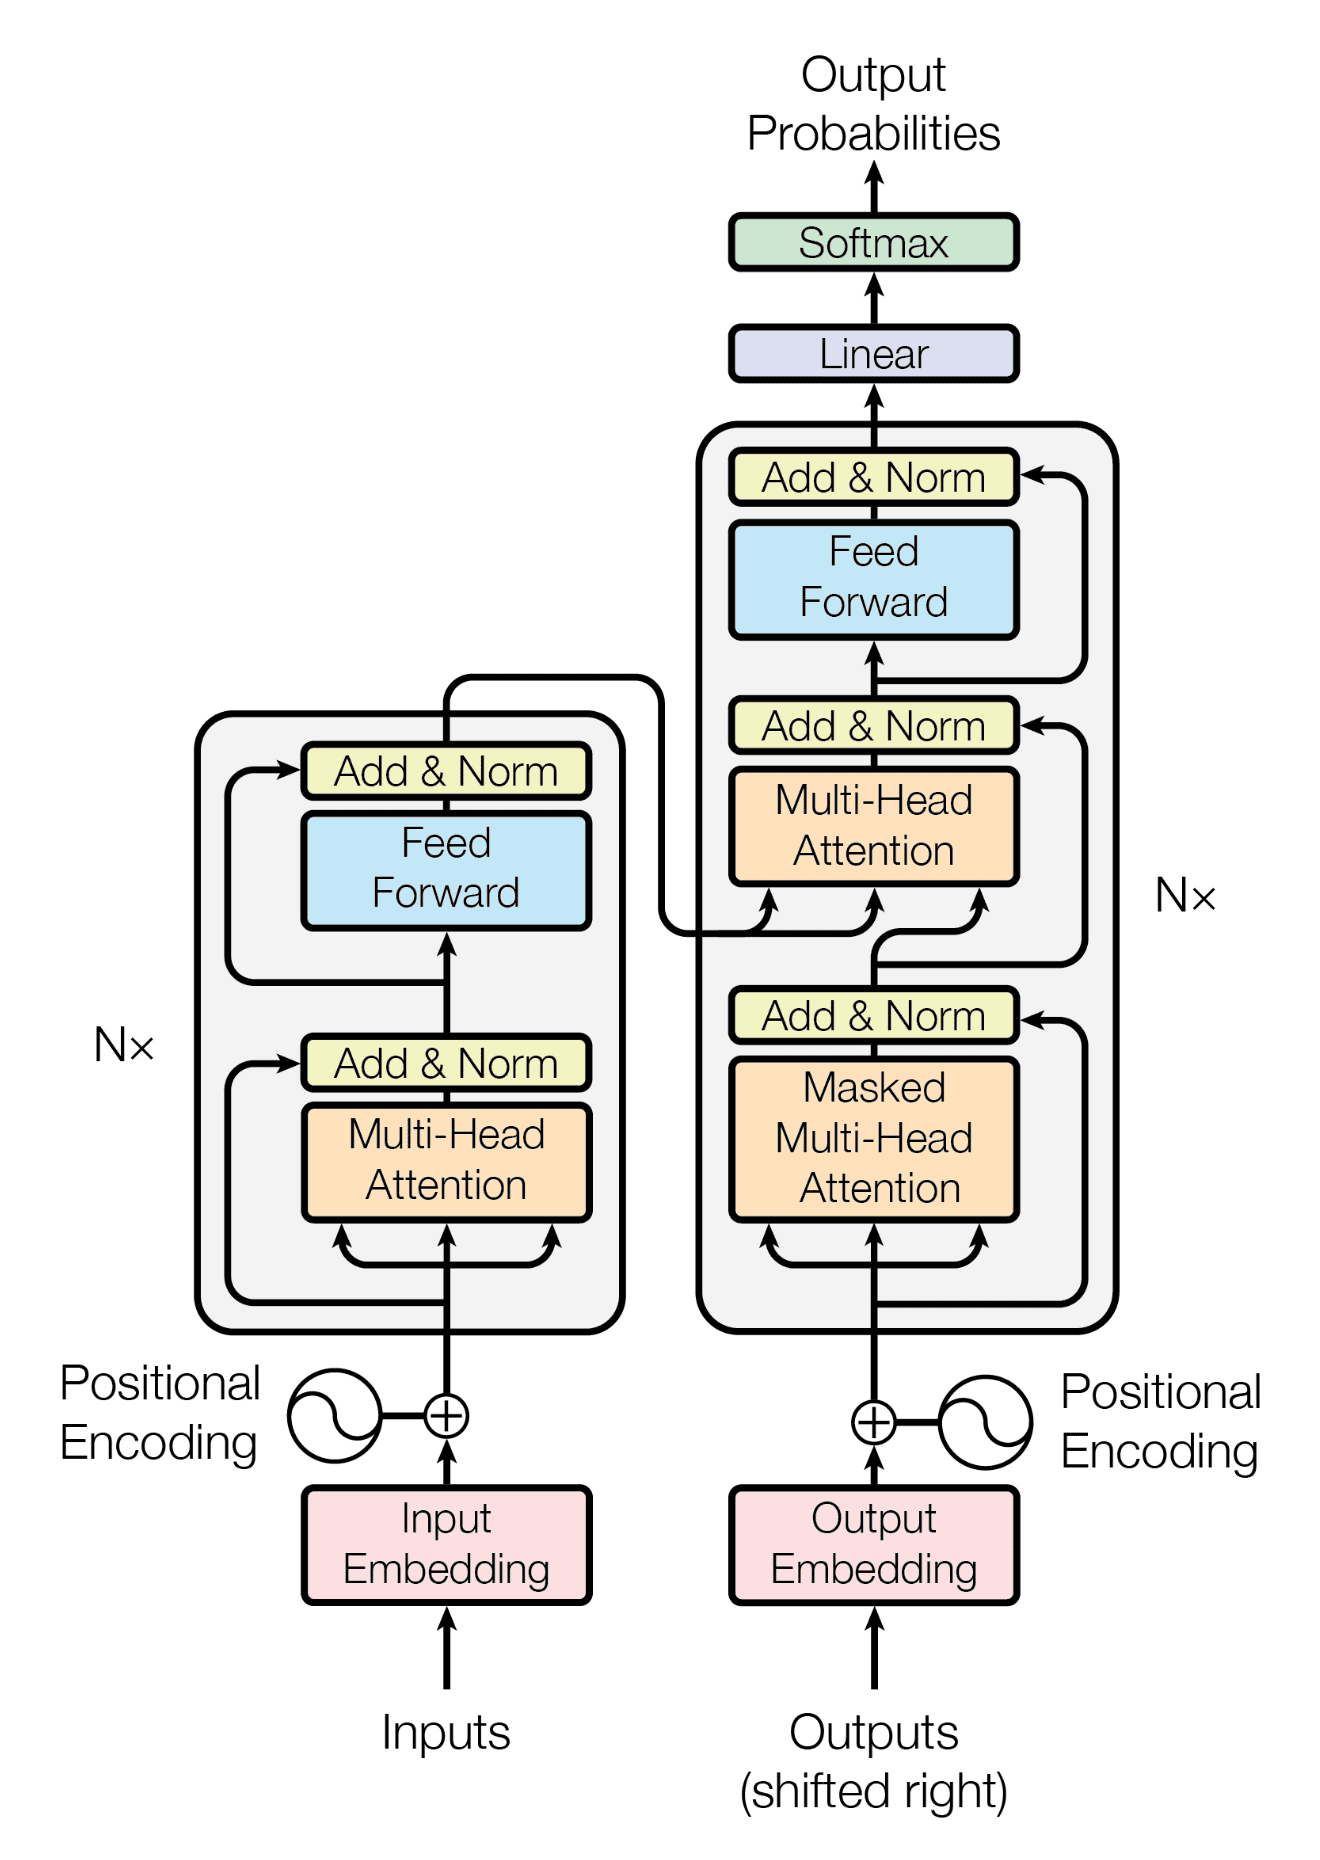
<figcaption>Figura 2: Arquitectura Transformer original: encoder,
decoder causal y cross-attention (<span class="citation"
data-cites="vaswani2017attention">Vaswani et al. (2017)</span>, Figure
1).</figcaption>
</figure>

Los LLM generativos actuales suelen utilizar una variante decoder-only.
En ella desaparecen el encoder y la cross-attention: una única pila de
bloques con self-attention causal transforma el contexto disponible y
produce los logits del siguiente token. Esto no significa que el
decoder-only sea “el Transformer completo”; es una variante
especializada para modelado de lenguaje causal.

| Variante | Máscara principal | Salida habitual | Ejemplos de uso |
|------------------|------------------|------------------|------------------|
| Encoder-only | Bidireccional | Representación contextual | Clasificación, NER, embeddings |
| Decoder-only | Causal | Logits del siguiente token | Generación, chat, código |
| Encoder-decoder | Encoder bidireccional + decoder causal + cross-attention | Secuencia de salida | Traducción, resumen, transformación de texto |

### Anatomía de un bloque moderno

La unidad que se repite $L$ veces no es solamente una capa de atención.
Un bloque moderno combina normalización, self-attention, conexiones
residuales y una red feed-forward. En una configuración Pre-Norm, una
forma simplificada de escribir sus dos subcapas es:

$$\mathbf{x}' = \mathbf{x} + \operatorname{MHA}(\operatorname{RMSNorm}(\mathbf{x}))$$

$$\mathbf{x}_{\text{salida}} = \mathbf{x}' + \operatorname{MLP}(\operatorname{RMSNorm}(\mathbf{x}'))$$

La figura
<a href="#fig-bloque-decoder-only" class="quarto-xref">Figura 3</a>
muestra el recorrido completo. La forma de la representación sigue
siendo $B \times T \times d$ después de cada subcapa; la proyección al
vocabulario aparece únicamente al final.

<figure id="fig-bloque-decoder-only">

<figcaption>Figura 3: Bloque Transformer decoder-only moderno con
RMSNorm, atención causal, conexiones residuales y MLP.</figcaption>
</figure>

Las conexiones residuales transportan una copia de la representación
alrededor de cada subcapa. Esto facilita que la red aprenda una
modificación de la representación en lugar de tener que reconstruirla
completamente en cada capa. La normalización mantiene las activaciones
en una escala manejable y la MLP transforma cada posición de forma
independiente.

La arquitectura original utilizaba normalmente Post-Norm, mientras que
muchos LLM modernos utilizan Pre-Norm o RMSNorm. No son nombres de
modelos distintos, sino órdenes diferentes de las mismas operaciones. La
elección afecta a la estabilidad del entrenamiento y a la facilidad para
optimizar redes muy profundas (Ba et al., 2016; Zhang & Sennrich, 2019).

### Atención multi-cabeza (Multi-Head Attention)

El núcleo del Transformer se encuentra en el mecanismo de *scaled
dot-product attention* (atención basada en el producto escalar). Dada
una matriz de estados $X \in \mathbb{R}^{B \times T \times d}$, el
modelo aprende tres proyecciones:

$$Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V$$

Las matrices $Q$, $K$ y $V$ no son tres copias del texto. Son tres
lecturas distintas de los mismos estados:

- **Q (Query):** qué información busca este token.
- **K (Key):** qué información ofrece cada token.
- **V (Value):** el contenido real de cada token.

A partir de estas proyecciones, la atención se calcula como:

$$\operatorname{Attention}(Q,K,V)
= \operatorname{softmax}\left(\frac{QK^\mathsf{T}}{\sqrt{d_k}} + M\right)V$$

El producto $QK^\mathsf{T}$ produce una puntuación para cada par de
posiciones. El factor $\sqrt{d_k}$ evita que los productos escalares
crezcan demasiado cuando aumenta la dimensión de las claves. La matriz
$M$ representa la máscara: contiene ceros en las posiciones permitidas y
$-\infty$ en las posiciones bloqueadas, de modo que el *softmax* les
asigna probabilidad cero.

En un encoder bidireccional, normalmente no se bloquean posiciones por
causalidad. En un decoder-only, la posición $t$ no puede consultar
posiciones futuras. Esta diferencia determina si el modelo puede
utilizar toda la secuencia para construir cada representación o si debe
mantener el orden de generación.

La atención multi-cabeza divide la dimensión en $H$ subespacios. Cada
cabeza calcula su propia atención y después sus resultados se concatenan
y se proyectan:

$$\operatorname{MHA}(X)
= \operatorname{Concat}(\operatorname{head}_1,\ldots,\operatorname{head}_H)W_O$$

Las cabezas no vienen etiquetadas de antemano como “sintaxis” o
“semántica”. Pueden aprender patrones diferentes, pero su interpretación
debe hacerse con cautela.

<figure id="fig-mascaras-atencion">

<figcaption>Figura 4: Comparación entre una máscara bidireccional y una
máscara causal.</figcaption>
</figure>

La figura
<a href="#fig-mascaras-atencion" class="quarto-xref">Figura 4</a>
muestra por qué la máscara es una restricción de información y no una
operación adicional del bloque. El cálculo matricial puede ejecutarse en
paralelo, pero cada posición solo recibe información de las celdas
permitidas.

<figure id="fig-sdpa-vs-mha">
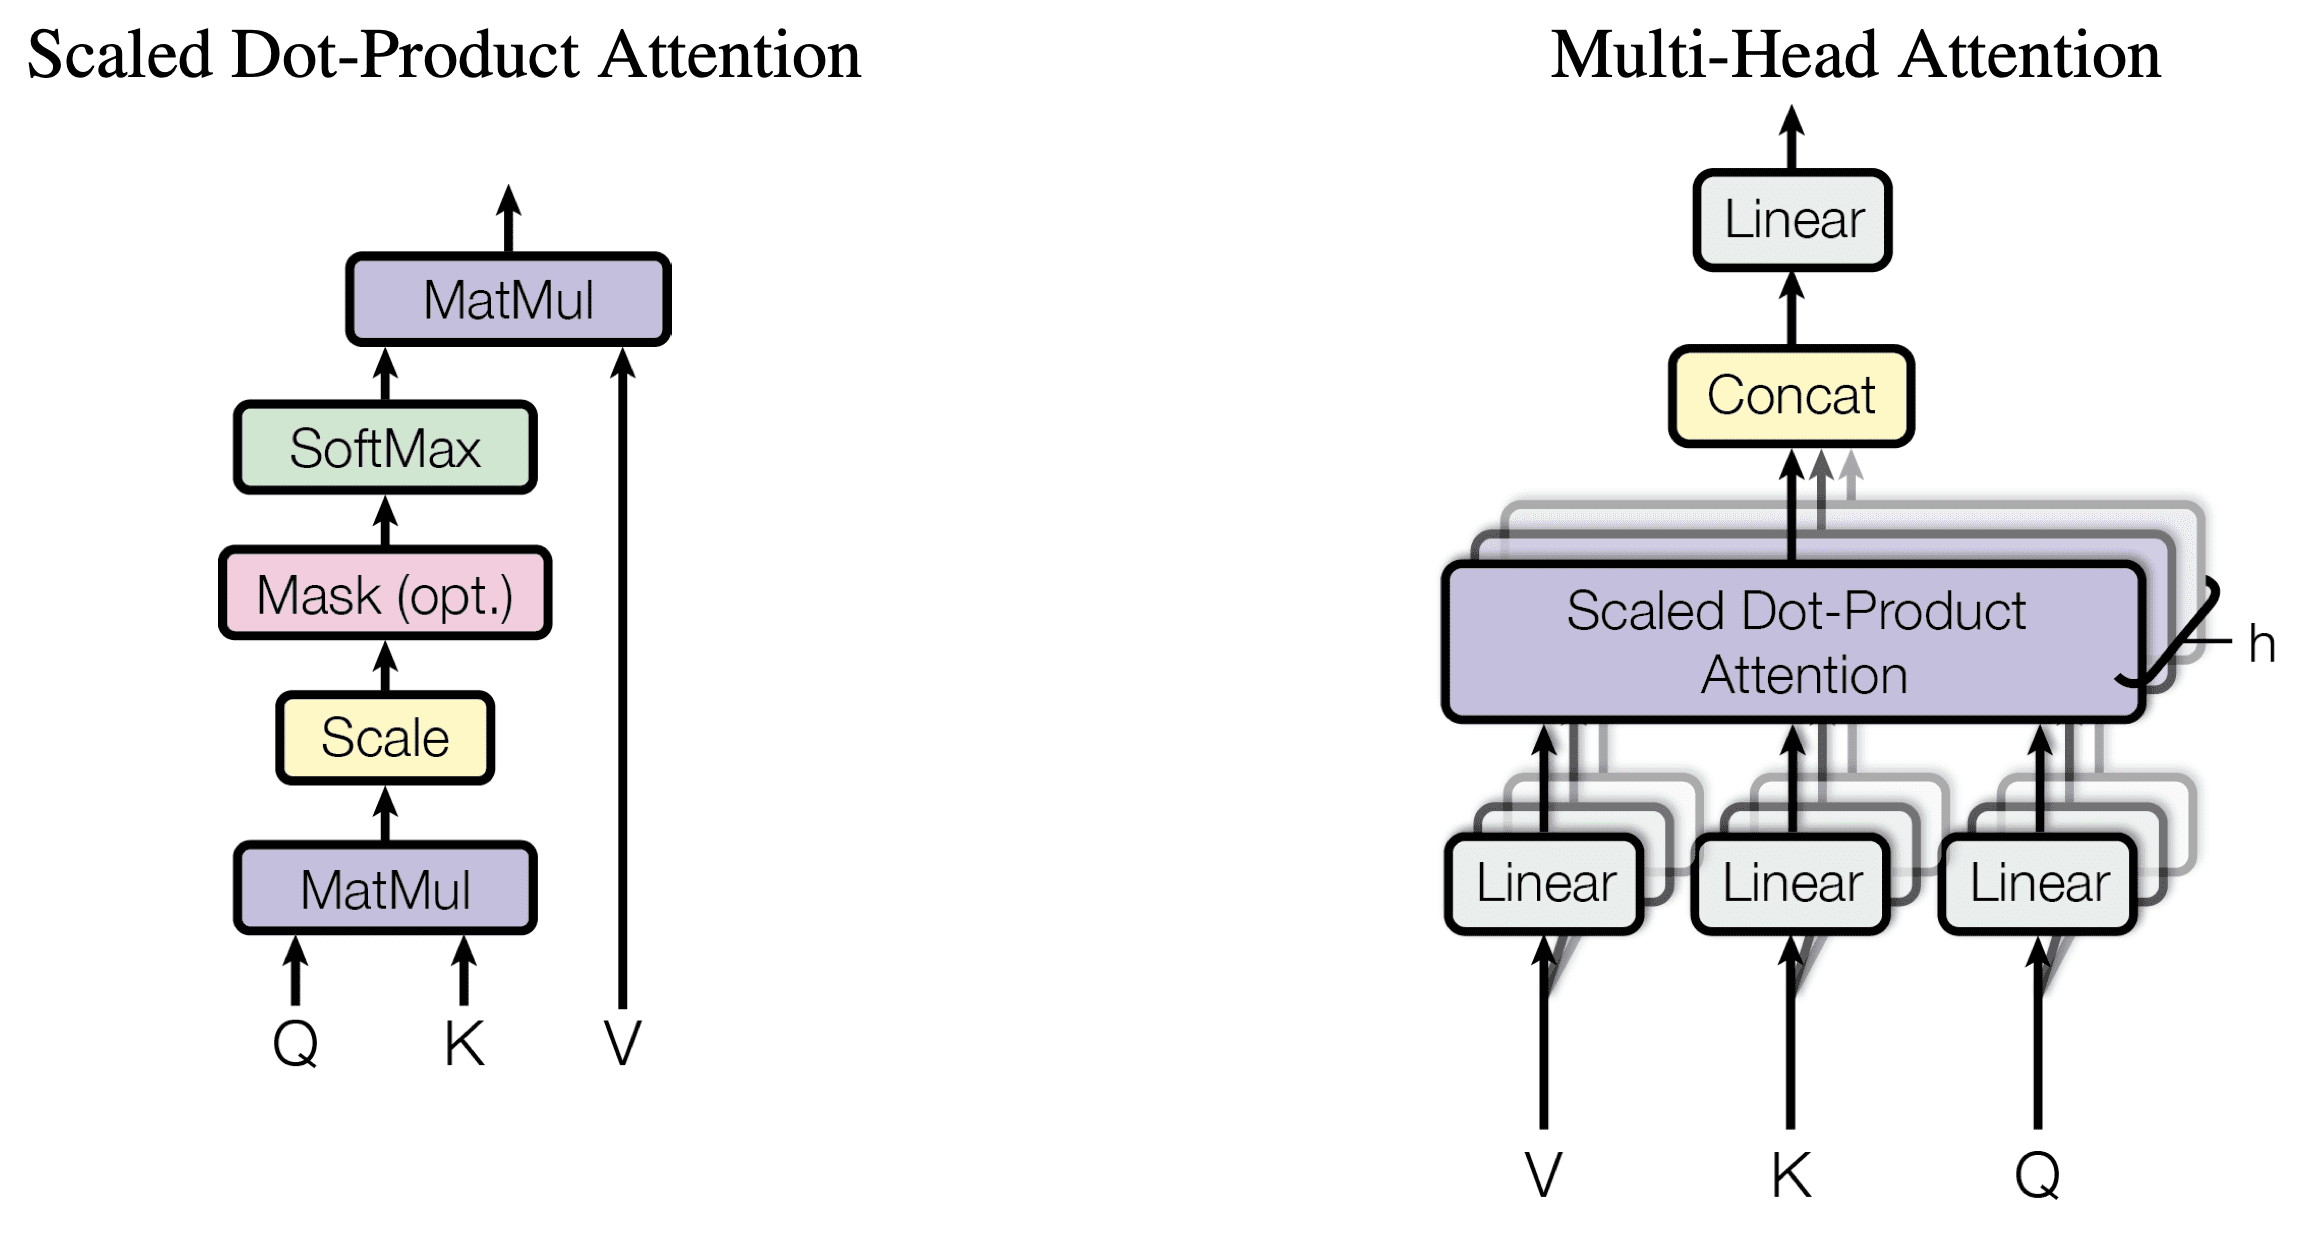
<figcaption>Figura 5: Scaled Dot-Product Attention (izquierda) y
Atención multi-cabeza (derecha) (<span class="citation"
data-cites="vaswani2017attention">Vaswani et al. (2017)</span>, Figure
2)</figcaption>
</figure>

#### Scaled Dot-Product Attention — Low Level (numpy)

La primera implementación calcula atención sin máscara para que se vea
la operación básica. Después aplicamos una máscara causal a la misma
función.

In [3]:
def scaled_dot_product_attention_numpy(Q, K, V, mask=None):
    """Atención paso a paso con numpy. Muestra la matemática subyacente."""
    d_k = K.shape[-1]
    scores = np.matmul(Q, K.transpose(0, 2, 1))
    scores = scores / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)
    scores = scores - np.max(scores, axis=-1, keepdims=True)
    weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
    output = np.matmul(weights, V)
    return output, weights

np.random.seed(42)
batch, seq_len, d_k = 1, 3, 4
Q = np.random.randn(batch, seq_len, d_k)
K = np.random.randn(batch, seq_len, d_k)
V = np.random.randn(batch, seq_len, d_k)

out_np, attn_np = scaled_dot_product_attention_numpy(Q, K, V)
print("Matriz de atención (numpy):")
print(np.round(attn_np[0], 3))
print("\nCada fila suma 1:", np.round(attn_np[0].sum(axis=1), 3))

causal_mask = np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)
_, attn_causal = scaled_dot_product_attention_numpy(Q, K, V, mask=causal_mask)
print("\nAtención causal (las posiciones futuras quedan a cero):")
print(np.round(attn_causal[0], 3))


Matriz de atención (numpy):
[[0.393 0.168 0.439]
 [0.231 0.283 0.486]
 [0.225 0.559 0.216]]

Cada fila suma 1: [1. 1. 1.]

Atención causal (las posiciones futuras quedan a cero):
[[1.    0.    0.   ]
 [0.449 0.551 0.   ]
 [0.225 0.559 0.216]]

#### Scaled Dot-Product Attention — High Level (PyTorch)

In [4]:
def scaled_dot_product_attention_torch(Q, K, V):
    """Atención paso a paso con PyTorch, equivalente a la versión numpy."""
    d_k = K.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)
    return output, weights

Qt = torch.from_numpy(Q)
Kt = torch.from_numpy(K)
Vt = torch.from_numpy(V)

out_th, attn_th = scaled_dot_product_attention_torch(Qt, Kt, Vt)
print("Matriz de atención (PyTorch):")
print(np.round(attn_th.numpy()[0], 3))

print(f"\n¿Resultados idénticos? {np.allclose(out_np, out_th.numpy(), atol=1e-6)}")


Matriz de atención (PyTorch):
[[0.393 0.168 0.439]
 [0.231 0.283 0.486]
 [0.225 0.559 0.216]]

¿Resultados idénticos? True

#### Multi-Head Attention — Low Level (numpy)

In [5]:
def multi_head_attention_numpy(Q, K, V, num_heads=2):
    """Multi-head atención desde cero: divide en cabezas, atiende, concatena, proyecta."""
    batch, seq_len, d_model = Q.shape
    d_k = d_model // num_heads

    Q_heads = Q.reshape(batch, seq_len, num_heads, d_k).transpose(0, 2, 1, 3)
    K_heads = K.reshape(batch, seq_len, num_heads, d_k).transpose(0, 2, 1, 3)
    V_heads = V.reshape(batch, seq_len, num_heads, d_k).transpose(0, 2, 1, 3)

    outputs, attn_weights = [], []
    for h in range(num_heads):
        scores = Q_heads[:, h] @ K_heads[:, h].swapaxes(-2, -1) / np.sqrt(d_k)
        weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
        outputs.append(weights @ V_heads[:, h])
        attn_weights.append(weights)

    concat = np.concatenate(outputs, axis=-1)
    return concat, attn_weights

Q_mh = np.random.randn(1, 3, 8)
K_mh = np.random.randn(1, 3, 8)
V_mh = np.random.randn(1, 3, 8)
out_mh, attn_mh = multi_head_attention_numpy(Q_mh, K_mh, V_mh, num_heads=2)
print(f"Salida multi-head: {out_mh.shape}")
print(f"Cabeza 0 pesos:\n{np.round(attn_mh[0][0], 3)}")
print(f"Cabeza 1 pesos:\n{np.round(attn_mh[1][0], 3)}")
print(f"\nCada cabeza atiende de forma distinta (diferentes pesos).")


Salida multi-head: (1, 3, 8)
Cabeza 0 pesos:
[[0.427 0.361 0.211]
 [0.307 0.588 0.105]
 [0.143 0.711 0.146]]
Cabeza 1 pesos:
[[0.384 0.34  0.277]
 [0.201 0.099 0.7  ]
 [0.34  0.282 0.377]]

Cada cabeza atiende de forma distinta (diferentes pesos).

#### Multi-Head Attention — High Level (PyTorch)

In [6]:
embed_dim = 8
num_heads = 2
mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

Qt_mh = torch.from_numpy(Q_mh).float()
Kt_mh = torch.from_numpy(K_mh).float()
Vt_mh = torch.from_numpy(V_mh).float()

out_th_mh, attn_th_mh = mha(Qt_mh, Kt_mh, Vt_mh, need_weights=True)
print(f"Salida nn.MultiheadAttention: {out_th_mh.shape}")
print(f"Pesos de atención:\n{np.round(attn_th_mh.detach().numpy(), 3)}")
print(f"\nParámetros entrenables de la capa: {sum(p.numel() for p in mha.parameters())}")


Salida nn.MultiheadAttention: torch.Size([1, 3, 8])
Pesos de atención:
[[[0.242 0.515 0.243]
  [0.277 0.391 0.332]
  [0.372 0.236 0.392]]]

Parámetros entrenables de la capa: 288

#### Visualización de atención

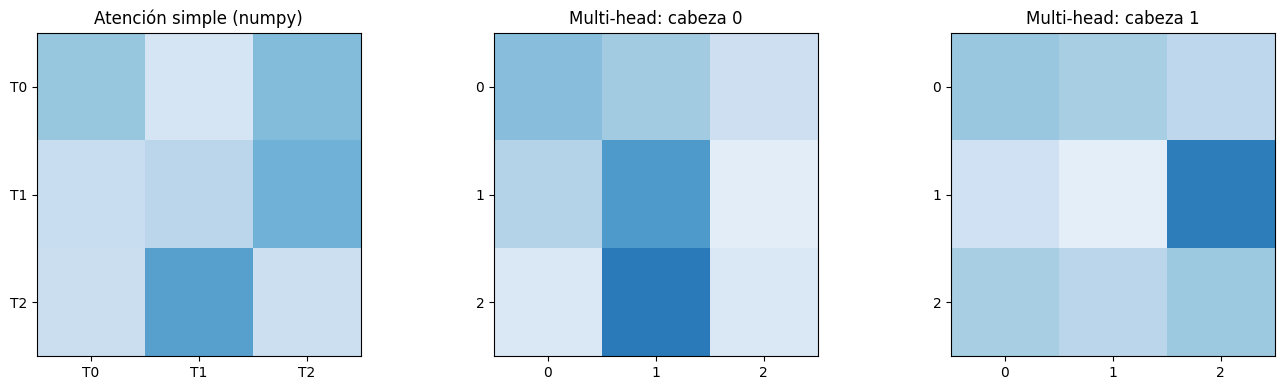

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(attn_np[0], cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Atención simple (numpy)")
axes[0].set_xticks(range(seq_len)); axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels([f"T{i}" for i in range(seq_len)])
axes[0].set_yticklabels([f"T{i}" for i in range(seq_len)])

axes[1].imshow(attn_mh[0][0], cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Multi-head: cabeza 0")
axes[1].set_xticks(range(seq_len)); axes[1].set_yticks(range(seq_len))

axes[2].imshow(attn_mh[1][0], cmap="Blues", vmin=0, vmax=1)
axes[2].set_title("Multi-head: cabeza 1")
axes[2].set_xticks(range(seq_len)); axes[2].set_yticks(range(seq_len))

plt.tight_layout()
plt.show()
plt.close(fig)


> **Atención no equivale a explicación**
>
> Un mapa de atención muestra cómo se distribuyen determinados pesos
> dentro de una capa y una cabeza. No demuestra por sí solo que esos
> tokens sean la causa de la respuesta del modelo. Para atribuir
> influencia hay que combinarlo con gradientes, ablaciones u otros
> métodos causales (Jain & Wallace, 2019).

### La red feed-forward: transformar cada posición

La atención mezcla información entre posiciones, pero no sustituye a la
transformación que se aplica dentro de cada posición. Esa segunda
función es la red feed-forward, también llamada MLP o FFN:

$$\operatorname{FFN}(\mathbf{x})
= W_2\,\sigma(W_1\mathbf{x}+\mathbf{b}_1)+\mathbf{b}_2$$

La misma MLP se aplica de forma independiente a cada token. Por eso la
atención tiene una función relacional, mientras que la MLP transforma el
contenido de cada estado sin mezclar directamente posiciones distintas.
En los LLM modernos es frecuente utilizar SwiGLU:

$$\operatorname{SwiGLU}(\mathbf{x})
= W_2\left(\operatorname{SiLU}(W_1\mathbf{x})\odot W_3\mathbf{x}\right)$$

Esta formulación utiliza una rama que modula a la otra mediante un
producto elemento a elemento. Las FFN también se han interpretado como
una forma de memoria asociativa: determinadas direcciones de entrada
activan transformaciones que recuperan patrones aprendidos (Geva et al.,
2021). Esta interpretación es útil como intuición, pero no significa que
cada neurona almacene un hecho aislado.

### Normalización y conexiones residuales

LayerNorm normaliza las características de un estado individual, no las
observaciones de un lote:

$$\operatorname{LayerNorm}(\mathbf{x})
= \boldsymbol{\gamma}\odot
\frac{\mathbf{x}-\mu}{\sqrt{\sigma^2+\epsilon}}
 + \boldsymbol{\beta}$$

En muchos LLM actuales se utiliza RMSNorm, que elimina el centrado por
la media:

$$\operatorname{RMSNorm}(\mathbf{x})
= \boldsymbol{\gamma}\odot
\frac{\mathbf{x}}{\sqrt{\frac{1}{d}\sum_{i=1}^{d}x_i^2+\epsilon}}$$

Las conexiones residuales añaden la entrada de una subcapa a su salida.
Esta ruta directa facilita el flujo de gradientes a través de muchas
capas. La diferencia entre las dos disposiciones más habituales es:

| Orden | Forma simplificada | Comentario |
|------------------------|------------------------|------------------------|
| Post-Norm | `LayerNorm(x + SubLayer(x))` | Usado en el Transformer original; puede ser más difícil de estabilizar en redes profundas |
| Pre-Norm | `x + SubLayer(LayerNorm(x))` | Habitual en LLM modernos; ofrece una ruta residual directa |

En la práctica, los detalles exactos dependen del modelo. No todos los
LLM emplean la misma normalización ni la misma variante de MLP (Ba
et al., 2016; Zhang & Sennrich, 2019).

### Coste de la atención

La atención densa compara cada posición con todas las demás. Para una
secuencia de longitud $T$, la matriz de puntuaciones tiene forma
$T \times T$ y el coste aproximado de calcularla es:

$$\text{tiempo} = O(T^2 d), \qquad
\text{memoria de la matriz} = O(T^2)$$

El crecimiento cuadrático explica por qué duplicar la ventana de
contexto no duplica, sino que cuadruplica aproximadamente el tamaño de
la matriz de atención. En la práctica, el coste total también depende
del número de capas, cabezas, dimensión oculta, precisión numérica y
tamaño del lote.

> **FlashAttention no cambia la arquitectura**
>
> FlashAttention reorganiza el cálculo en bloques para reducir
> movimientos de memoria y evitar materializar toda la matriz de
> atención en la memoria de la GPU (Dao et al., 2022). Mejora la
> ejecución de la atención exacta, pero no convierte automáticamente el
> coste cuadrático en lineal. Las ventanas locales y las máscaras
> dispersas son decisiones diferentes.

### MHA, MQA y GQA

En la atención multi-cabeza estándar, cada cabeza tiene sus propias
proyecciones de consultas, claves y valores. En *Multi-Query Attention*
(MQA), varias cabezas de consulta comparten las mismas claves y valores.
*Grouped-Query Attention* (GQA) ocupa una posición intermedia: agrupa
varias cabezas de consulta para compartir un conjunto más pequeño de
cabezas K/V.

La ventaja aparece sobre todo durante la inferencia. El modelo debe
conservar las claves y valores de los tokens anteriores en la caché KV;
si hay menos cabezas K/V, esa caché ocupa menos memoria. Muchos LLM
modernos utilizan GQA como compromiso entre calidad y coste
(<span class="nocase">Grattafiori et al.</span>, 2024).

La atención local, GQA y FlashAttention resuelven problemas distintos.
La primera limita qué posiciones se consultan; la segunda reduce el
número de representaciones K/V almacenadas; la tercera optimiza cómo se
ejecuta el cálculo.

### Codificación posicional

Sin información posicional, la self-attention no distingue el orden de
los tokens. Más precisamente, el mecanismo es equivariante a
permutaciones: si permutamos la entrada y aplicamos la misma permutación
a la salida, el resultado se transforma de forma coherente, pero no
aparece ninguna noción de “antes” y “después”. Para inyectar esa
información, el Transformer añade o incorpora una señal posicional.

La codificación posicional sinusoidal usa frecuencias diferentes para
cada dimensión:

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

#### Codificación posicional — Low Level (numpy)

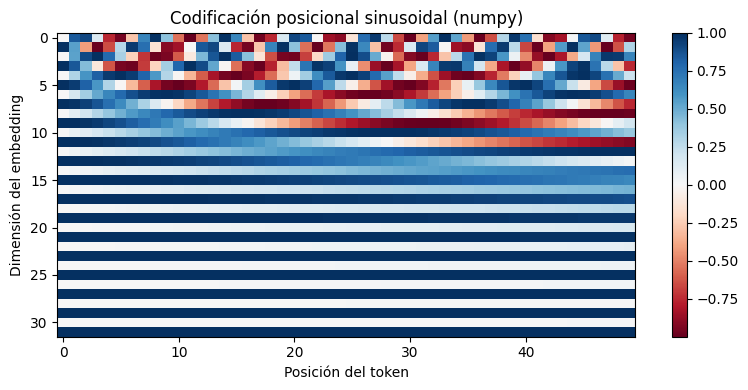

In [8]:
def positional_encoding_numpy(seq_len, d_model):
    """Codificación posicional sinusoidal desde cero."""
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / d_model)
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(pos * angle_rates[:, 0::2])
    pe[:, 1::2] = np.cos(pos * angle_rates[:, 1::2])
    return pe

pe_np = positional_encoding_numpy(50, 32)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pe_np.T, cmap="RdBu", aspect="auto")
ax.set_xlabel("Posición del token")
ax.set_ylabel("Dimensión del embedding")
ax.set_title("Codificación posicional sinusoidal (numpy)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
plt.close(fig)


#### Codificación posicional — High Level (PyTorch)

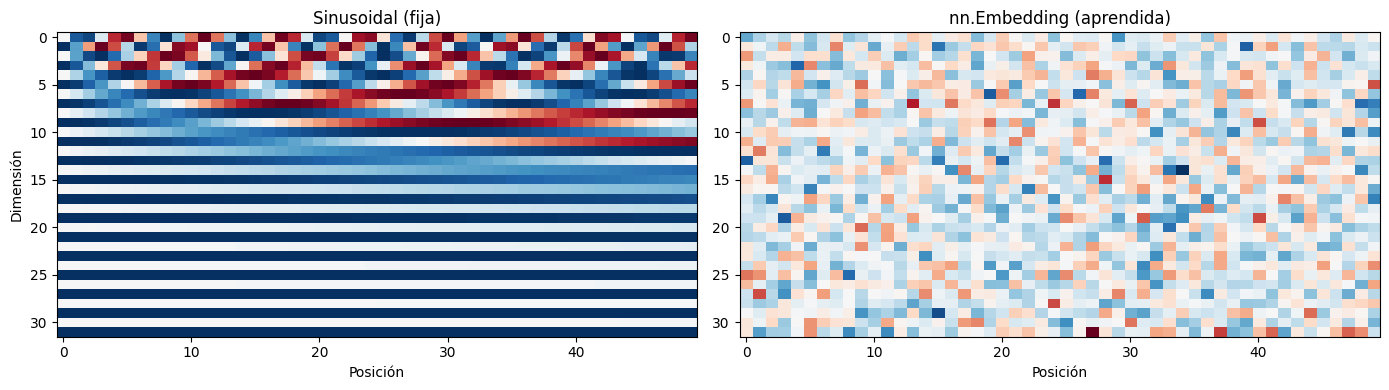

La versión aprendida se adapta a los datos; la sinusoidal es fija pero extrapola a secuencias más largas.

In [9]:
vocab_size = 50
d_model = 32
pos_embedding = nn.Embedding(vocab_size, d_model)

posiciones = torch.arange(vocab_size)
pe_aprendida = pos_embedding(posiciones).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(pe_np.T, cmap="RdBu", aspect="auto")
axes[0].set_title("Sinusoidal (fija)")
axes[0].set_xlabel("Posición"); axes[0].set_ylabel("Dimensión")

axes[1].imshow(pe_aprendida.T, cmap="RdBu", aspect="auto")
axes[1].set_title("nn.Embedding (aprendida)")
axes[1].set_xlabel("Posición")

plt.tight_layout()
plt.show()
plt.close(fig)
print("La versión aprendida se adapta a los datos; la sinusoidal es fija pero extrapola a secuencias más largas.")


### Posiciones relativas: RoPE y ALiBi

La codificación sinusoidal y la aprendida absoluta se incorporan
normalmente a los embeddings. Los LLM modernos suelen utilizar
alternativas que introducen la posición directamente en la atención. La
más extendida es RoPE (*Rotary Position Embedding*), que rota las
componentes de las consultas y las claves según su posición.

Si $R_m$ representa la rotación asociada a la posición $m$, RoPE
calcula:

$$Q'_m = R_m Q_m, \qquad K'_n = R_n K_n$$

La propiedad importante es que el producto $Q_m'K_n'^{\mathsf{T}}$
incorpora información sobre la posición relativa $m-n$. No hace falta
memorizar la derivación completa para entender su utilidad: la atención
puede distinguir dos tokens por su contenido y por la distancia que los
separa (Su et al., 2021).

Otra alternativa es ALiBi, que no añade vectores posicionales, sino que
incorpora un sesgo dependiente de la distancia directamente en los
logits de atención. Favorece, de forma gradual, la atención a posiciones
cercanas (Press et al., 2022).

| Método | Cómo introduce la posición | Ventaja principal | Limitación principal |
|------------------|------------------|------------------|------------------|
| Sinusoidal | Suma funciones seno y coseno a los embeddings | No añade parámetros aprendibles | La extrapolación práctica es limitada |
| Absoluta aprendida | Aprende un vector para cada posición | Flexible en la longitud entrenada | Depende de una longitud máxima |
| RoPE | Rota Q y K según la posición | Relación relativa y buena compatibilidad con KV cache | Requiere estrategias de extensión para contextos mucho mayores |
| ALiBi | Añade un sesgo lineal a los scores | Sencillo y con buena extrapolación | Introduce una preferencia fuerte por la cercanía |

La codificación posicional no es un detalle cosmético. Cambia la
geometría de las puntuaciones de atención y, por tanto, la forma en que
el modelo utiliza el contexto.

### Variantes de la arquitectura

| Variante | Objetivo habitual | Ejemplos | Uso principal |
|------------------|------------------|------------------|------------------|
| Encoder-only | Modelado enmascarado o clasificación | BERT, RoBERTa | Clasificación, NER, embeddings |
| Decoder-only | Modelado causal del siguiente token | GPT, Llama, Qwen, Gemma | Generación de texto, chat y código |
| Encoder-decoder | Transformación de una secuencia en otra | T5, BART | Traducción, resumen y QA |

Tabla 1: Comparativa de las tres variantes principales de la
arquitectura Transformer

BERT es un ejemplo de encoder-only entrenado con objetivos
bidireccionales (Devlin et al., 2019). T5 representa la familia
encoder-decoder que formula muchas tareas como transformación de texto a
texto (Raffel et al., 2020). Los LLM conversacionales actuales suelen
pertenecer a la familia decoder-only, aunque sus etapas de instrucción y
alineamiento se estudian por separado en [01e - Del estado oculto a la
salida](01e-llm-por-dentro.qmd).

<figure id="fig-variantes-transformer">
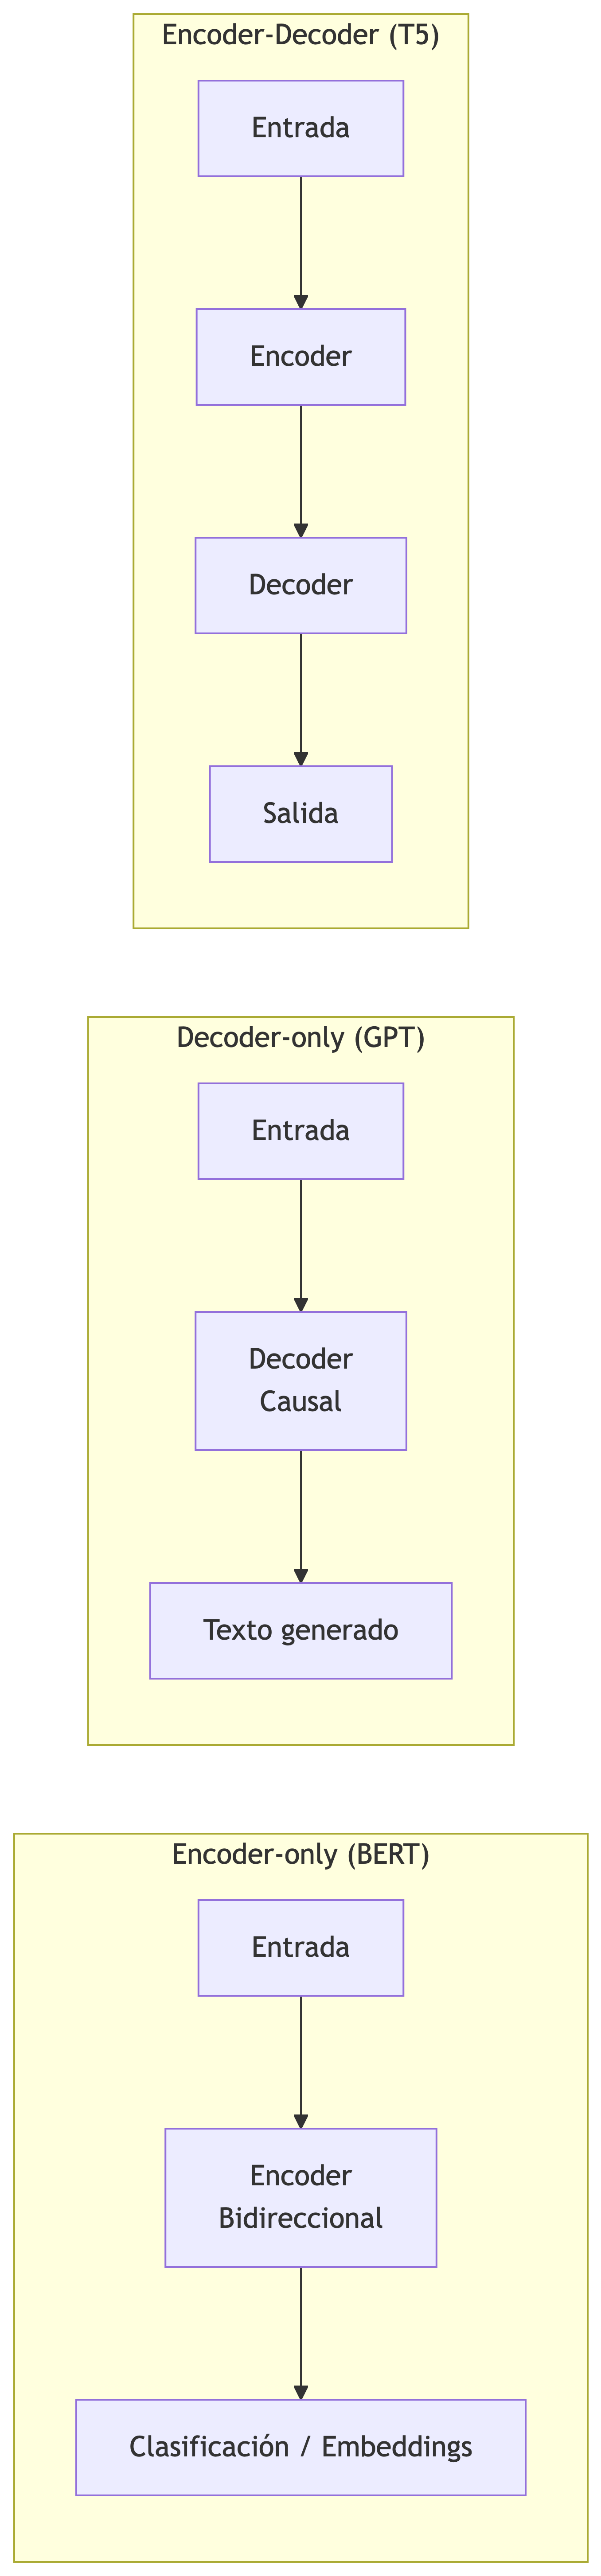
<figcaption>Figura 6</figcaption>
</figure>

La elección no es una cuestión de antigüedad. Depende de la relación
entre la entrada y la salida. Si necesitamos una representación
contextual de toda la entrada, un encoder-only puede ser suficiente. Si
queremos generar una continuación, un decoder-only ofrece una interfaz
natural. Si la tarea tiene una entrada y una salida con papeles
diferenciados, el encoder-decoder mantiene esa separación mediante
cross-attention.

### Entrenamiento paralelo e inferencia autorregresiva

En un modelo causal, la frase “predecir el siguiente token” describe el
objetivo, no necesariamente el orden de las operaciones durante el
entrenamiento. Dada una secuencia, se desplazan los objetivos una
posición:

``` text
Entrada:  [El, modelo, aprende, con, datos]
Objetivo:  [modelo, aprende, con, datos, nuevos]
```

El modelo puede calcular las predicciones de todas las posiciones en un
único *forward pass*, siempre que la máscara causal impida que una
posición consulte el futuro. Este procedimiento se conoce como *teacher
forcing*: cada posición recibe como contexto los tokens reales
anteriores, no los tokens que el modelo haya generado en pasos
anteriores.

Durante la inferencia, la situación cambia. El modelo genera un token,
lo añade al contexto y vuelve a producir una distribución. Los sistemas
de producción suelen conservar las claves y valores ya calculados en una
caché KV para no repetir todo el trabajo en cada paso. Así aparecen dos
fases con perfiles distintos:

| Fase | Qué ocurre | Cuello de botella habitual |
|------------------------|------------------------|------------------------|
| Prefill | Se procesa el prompt completo y se construye la caché KV | Cómputo y paralelismo |
| Decode | Se genera un token por secuencia y se consulta la caché | Memoria y ancho de banda |

> **Dos afirmaciones que no se contradicen**
>
> El Transformer procesa muchas posiciones en paralelo durante el
> entrenamiento, pero genera una respuesta token a token durante la
> inferencia. La máscara causal mantiene la misma restricción de
> información en las dos fases.

> **Lectura obligatoria**
>
> Vaswani et al. (2017)
>
> Leer secciones 3-5: Scaled Dot-Product Attention, Multi-Head
> Attention, Positional Encoding y el resumen de la arquitectura
> completa.

------------------------------------------------------------------------

> Continúa con **[01b-llms.qmd](01b-llms.qmd)** — Grandes Modelos de
> Lenguaje e inferencia.

# References

Ba, J. L., Kiros, J. R., & Hinton, G. E. (2016). Layer Normalization.
*arXiv preprint arXiv:1607.06450*. <https://arxiv.org/abs/1607.06450>

Dao, T., Fu, D. Y., Ermon, S., Rudra, A., & Ré, C. (2022).
FlashAttention: Fast and Memory-Efficient Exact Attention with
IO-Awareness. *Advances in Neural Information Processing Systems*.
<https://arxiv.org/abs/2205.14135>

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT:
Pre-training of Deep Bidirectional Transformers for Language
Understanding. *Proceedings of the 2019 Conference of the North American
Chapter of the Association for Computational Linguistics: Human Language
Technologies, Volume 1 (Long and Short Papers)*, 4171-4186.
<https://doi.org/10.18653/v1/N19-1423>

Geva, M., Schuster, R., Berant, J., & Levy, O. (2021). Transformer
Feed-Forward Layers Are Key-Value Memories. *Proceedings of the 2021
Conference on Empirical Methods in Natural Language Processing*.
<https://aclanthology.org/2021.emnlp-main.446/>

<span class="nocase">Grattafiori, A., Dubey, A., Jauhri, A.,
et al.</span> (2024). The Llama 3 Herd of Models. *arXiv preprint
arXiv:2407.21783*. <https://arxiv.org/abs/2407.21783>

Jain, S., & Wallace, B. C. (2019). Attention is Not Explanation.
*Proceedings of the 2019 Conference of the North American Chapter of the
Association for Computational Linguistics*, 3543-3556.
<https://aclanthology.org/N19-1357/>

Press, O., Smith, N. A., & Lewis, M. (2022). Train Short, Test Long:
Attention with Linear Biases Enables Input Length Generalization.
*International Conference on Learning Representations*.
<https://arxiv.org/abs/2108.12409>

Raffel, C., Shazeer, N., Roberts, A., Lee, K., Narang, S., Matena, M.,
Zhou, Y., Li, W., & Liu, P. J. (2020). Exploring the Limits of Transfer
Learning with a Unified Text-to-Text Transformer. *Journal of Machine
Learning Research*, *21*(140), 1-67. <https://arxiv.org/abs/1910.10683>

Su, J., Lu, Y., Pan, S., Wen, B., & Liu, Y. (2021). RoFormer: Enhanced
Transformer with Rotary Position Embedding. *arXiv preprint
arXiv:2104.09864*. <https://arxiv.org/abs/2104.09864>

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez,
A. N., Kaiser, L., & Polosukhin, I. (2017). *Attention is All You Need*.
*30*. <https://arxiv.org/abs/1706.03762>

Zhang, B., & Sennrich, R. (2019). Root Mean Square Layer Normalization.
*Advances in Neural Information Processing Systems*.
<https://arxiv.org/abs/1910.07467>